## Phase 4 - Anomaly Detection: Isolation Forest

This notebook implements an unsupervised anomaly detection model using the Isolation Forest algorithm.
Unlike the supervised models in Phase 3, Isolation Forest does not use labels during training — 
instead it learns the underlying distribution of normal network traffic and flags deviations as anomalies.

### Motivation

Supervised models are limited to detecting attack types they have been trained on. In a real-world 
defence context, novel or zero-day attacks will not match any known pattern. An unsupervised approach 
addresses this gap by learning what "normal" looks like and raising alerts on anything that deviates 
significantly — regardless of whether that attack type has been seen before.

### Approach

- **Training data:** BENIGN traffic only (`y_train == 0`) — the model learns a pure definition of normal
- **Contamination:** Set to 0.17, reflecting the approximate proportion of attack traffic in the dataset
- **Evaluation:** Predictions are mapped to a binary label (normal vs anomaly) and evaluated against 
  the true labels from the test set
- **Integration:** Results are compared against XGBoost to explore a combined detection approach 
  where Isolation Forest flags anomalies and XGBoost classifies known attack types

### Key distinction from Phase 3

The evaluation framing here is binary — normal vs anomaly — rather than multiclass. A successful 
result means the model correctly surfaces attack traffic it has never explicitly been trained to recognise.

In [20]:
import numpy as np
import joblib
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns


# Load the preprocessed data from .npy files
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')
network_dataset_encoder = joblib.load('../models/label_encoder.pkl')

# Filtering the training data to only include the 'Normal' class (label 0)
benign_traffic = X_train[y_train == 0]
benign_labels = y_train[y_train == 0]

print(f"Benign traffic shape: {benign_traffic.shape}")



Benign traffic shape: (1676045, 51)


/opt/anaconda3/envs/anomaly-detector/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
#Training the Isolation Forest model
network_dataset_iforest = IsolationForest(n_estimators=100, contamination=0.17, random_state=42)
network_dataset_iforest.fit(benign_traffic)

# Save the trained model
joblib.dump(network_dataset_iforest, '../models/network_dataset_iforest.pkl')



['../models/network_dataset_iforest.pkl']

**Model fitted and Trained** Now to test and evaluate using 1 for normal traffic and -1 for attacks

In [22]:
# Predicting anomalies on the test set
y_pred_iforest = network_dataset_iforest.predict(X_test)
classes = {'Malicious': -1, 'Benign': 1}
y_test_converted = np.where(y_test == 0, 1, -1)

# Evaluating the model
print(classification_report(y_test_converted, y_pred_iforest, target_names=[class_name for class_name in classes.keys()]))
f1_score_iforest = f1_score(y_test_converted, y_pred_iforest, average='macro')
print(f"F1 Score (Macro): {f1_score_iforest:.4f}")
precision_score_iforest = precision_score(y_test_converted, y_pred_iforest, average='macro')
print(f"Precision Score (Macro): {precision_score_iforest:.4f}")
recall_score_iforest = recall_score(y_test_converted, y_pred_iforest, average='macro')
print(f"Recall Score (Macro): {recall_score_iforest:.4f}")


with open('../reports/classification_report_iforest.txt', 'w') as f:
    f.write(classification_report(y_test_converted, y_pred_iforest, target_names=[class_name for class_name in classes.keys()]))







              precision    recall  f1-score   support

   Malicious       0.42      0.60      0.50     85148
      Benign       0.91      0.83      0.87    419012

    accuracy                           0.79    504160
   macro avg       0.67      0.72      0.68    504160
weighted avg       0.83      0.79      0.81    504160

F1 Score (Macro): 0.6822
Precision Score (Macro): 0.6657
Recall Score (Macro): 0.7171


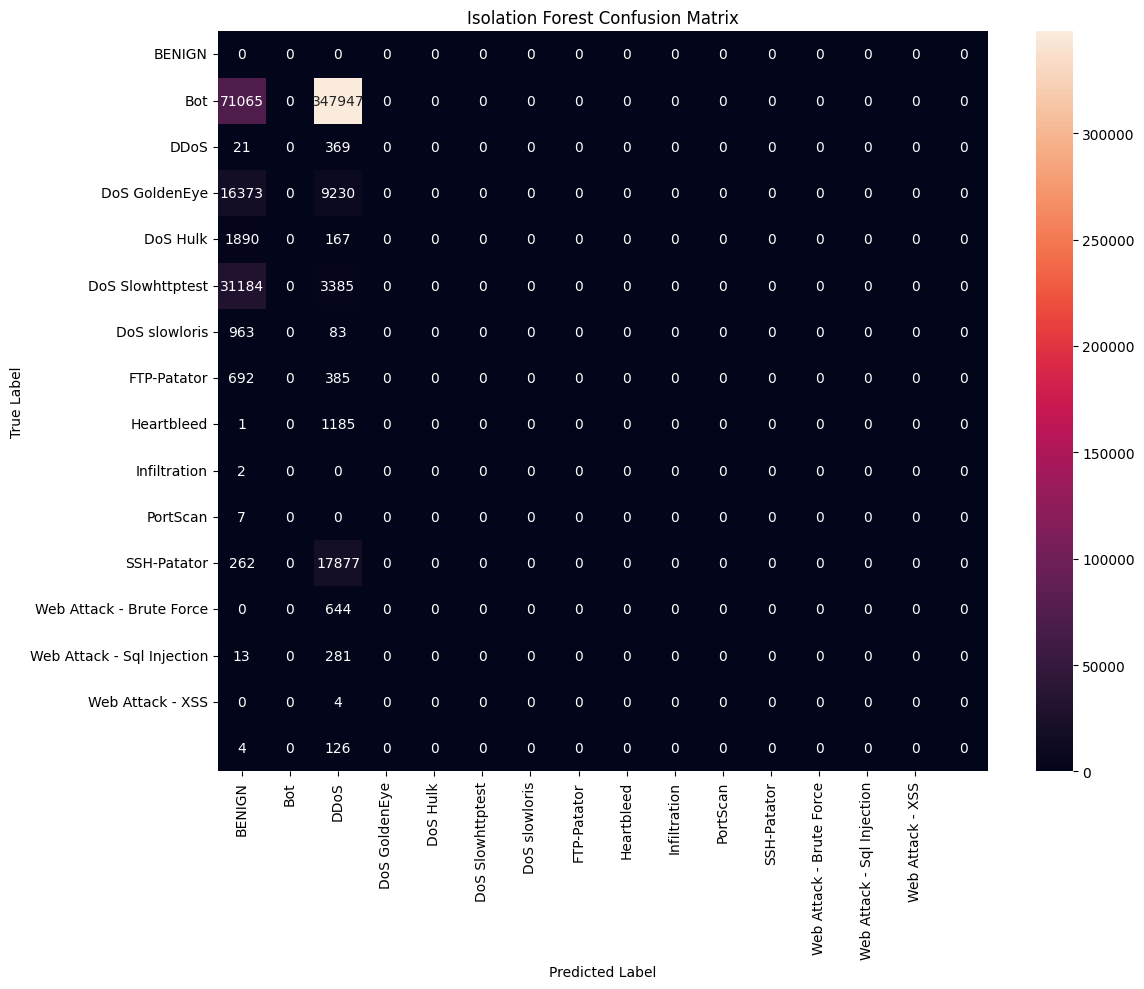

In [23]:
conf_matrix_iforest = confusion_matrix(y_test, y_pred_iforest)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_iforest, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('Isolation Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/iforest_confusion_matrix.png')

## Isolation Forest - Results

| Metric | Malicious | Benign |
|--------|-----------|--------|
| Precision | 0.42 | 0.91 |
| Recall | 0.60 | 0.83 |
| F1 Score | 0.50 | 0.87 |
| **Macro F1** | **0.68** | |

### Interpretation

The Isolation Forest achieved a macro F1 of 0.68 without using a single attack label during 
training — trained exclusively on BENIGN traffic, it learned the distribution of normal network 
behaviour and flagged deviations as anomalies.

**Malicious recall of 0.60** is the headline result — the model surfaces 60% of attack traffic 
purely by recognising it as abnormal relative to normal patterns. This is a strong result for 
unsupervised detection and demonstrates the value of anomaly-based approaches in security contexts.

**The main weakness is precision (0.42)** — of everything flagged as anomalous, 58% are false 
alarms. In isolation this would generate excessive noise for an analyst. However, this limitation 
is addressed in the next section where Isolation Forest is combined with XGBoost — the supervised 
model filters and classifies flagged anomalies, significantly reducing false positives.

### Comparison with supervised models

Unlike the Phase 3 models, Isolation Forest is not directly comparable on macro F1 — it solves 
a different problem. Where supervised models classify known attack types, Isolation Forest detects 
deviation from normal regardless of attack type. Its value is in catching **novel or zero-day 
attacks** that supervised models would miss entirely.

In [24]:

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="Isolation_Forest",):
    
    mlflow.log_metric("f1_macro", f1_score_iforest)
    mlflow.log_param("epochs", 20)
    mlflow.log_param("batch_size", 512)
    mlflow.log_param("architecture", "128-64-32")
    mlflow.log_metric("recall", recall_score_iforest)
    mlflow.log_metric("precision", precision_score_iforest)
    mlflow.log_artifact("../reports/classification_report_iforest.txt")
    mlflow.log_artifact("../reports/iforest_confusion_matrix.png")
    mlflow.sklearn.log_model(network_dataset_iforest, name="model")

2026/04/05 15:12:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


### Summary

Isolation Forest demonstrated that meaningful anomaly detection is achievable without any labelled 
attack data. Trained exclusively on BENIGN traffic, the model correctly flagged 60% of attack 
traffic as anomalous — purely by recognising deviation from normal network behaviour.

The primary limitation is precision — a false positive rate of 58% would generate excessive noise 
in a standalone deployment. However this is an inherent tradeoff of unsupervised detection and is 
addressed in the next section through combination with XGBoost.

The model is saved to `models/` and logged to MLflow for comparison alongside the supervised models.